<a href="https://colab.research.google.com/github/Seperoth/Valencia-Jose-Gabriel-CS0065-AN43/blob/main/EarlyWarningAN43.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install pandas scikit-learn seaborn joblib


In [5]:
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from google.colab import files
upload = files.upload()

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.pipeline import make_pipeline

from sklearn.preprocessing import MinMaxScaler

from sklearn.tree import DecisionTreeClassifier




Saving student_performance_knime.csv to student_performance_knime.csv


In [6]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print("Number of records:",len(df))
df.head(30)

Saving student_performance_knime.csv to student_performance_knime (1).csv
Number of records: 30


,student_id,attendance,quiz_score,assignment_score,exam_score,risk_status
0,S001,95,90,92,88,Not At Risk
1,S002,88,84,86,82,Not At Risk
2,S003,76,72,75,70,Not At Risk
3,S004,62,58,60,55,At Risk
4,S005,55,48,52,50,At Risk
5,S006,91,87,89,85,Not At Risk
6,S007,68,65,61,60,At Risk
7,S008,82,78,80,76,Not At Risk
8,S009,47,50,45,48,At Risk
9,S010,73,69,72,68,Not At Risk


In [9]:
features = ["attendance",
            "quiz_score",
            "assignment_score",
            "exam_score"
            ]
X = df[features]
y= df["risk_status"]

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training records:",len(X_train))
print("Testing records:",len(X_test))

Training records: 24
Testing records: 6


In [13]:
models = {"Logistic Regression": make_pipeline(
    MinMaxScaler(), LogisticRegression(max_iter=1000, random_state=42)
),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100,
                                            random_state=42)
}

In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix as sklearn_confusion_matrix
)

results = []
confusion_matrices = {}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predict
    predictions = model.predict(X_test)

    # Count errors
    errors = (predictions != y_test).sum()

    # Create confusion matrix
    matrix = sklearn_confusion_matrix(
        y_test,
        predictions,
        labels=["At Risk", "Not At Risk"]
    )

    confusion_matrices[name] = matrix

    # Store evaluation results
    results.append({
        "Algorithm": name,
        "Correct Predictions": len(y_test) - errors,
        "Errors": errors,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test,
            predictions,
            pos_label="At Risk",
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            pos_label="At Risk",
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_test,
            predictions,
            pos_label="At Risk",
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

results_df

,Algorithm,Correct Predictions,Errors,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,5,1,0.833333,1.000000,0.8,0.888889
1,Decision Tree,5,1,0.833333,0.833333,1.0,0.909091
2,Random Forest,6,0,1.000000,1.000000,1.0,1.000000


,Algorithm,Correct Predictions,Errors,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,5,1,0.833333,1.000000,0.8,0.888889
1,Decision Tree,5,1,0.833333,0.833333,1.0,0.909091
2,Random Forest,6,0,1.000000,1.000000,1.0,1.000000


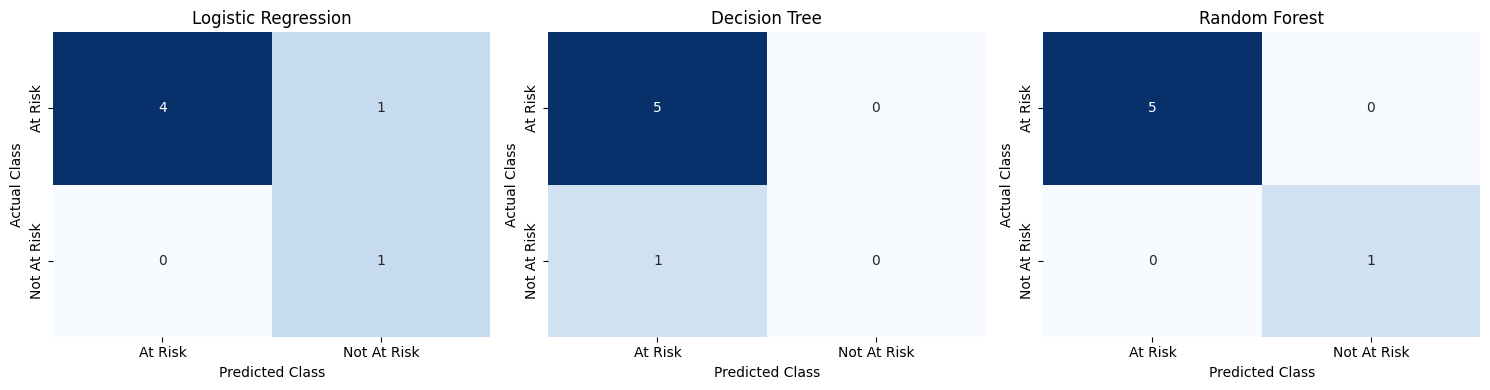

In [17]:
results_df = pd.DataFrame(results)
display(results_df)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for axis, (name, matrix) in zip(
    axes,
    confusion_matrices.items()
):
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["At Risk", "Not At Risk"],
        yticklabels=["At Risk", "Not At Risk"],
        ax=axis
    )

    axis.set_title(name)
    axis.set_xlabel("Predicted Class")
    axis.set_ylabel("Actual Class")

plt.tight_layout()
plt.show()